# Chulwon's Step by Step Data Analysis and Prediciton

# I. Data Analysis Process

## 01. Problem Solving Step
1. Step 1 : Define Problem
    -  Define the current issues faced by the company, dividing them into problem phenomena and the resulting damages to the company. 
    - At this stage, outline the task in a way that describes the problem phenomena with data.


2. Step 2. Expected Effects
    -  Define the expected effects of resolving the problem phenomena identified in 'Step 1.'
    - Expected effects should be expressed quantitatively rather than qualitatively.


3. Step 3. Solution
    - If the expected effects of resolving the defined problem are negligible, consider dropping the task.
    - If the expected effects are significant and the task is deemed necessary, explore and list possible solutions.
    -  Solutions do not necessarily need to involve modeling (e.g., simple statistical analysis may suffice).


4. Step 4. Prioritize
    - Set priorities for the listed solutions.
    - Execute the methods that can be implemented quickly and yield results most efficiently as the top priority.
    - Prepare secondary and tertiary methods as alternatives in case the first-priority method is ineffective.


5. Step 5. Data Analysis
    - Perform data analysis using the solution selected in step 4


6. Step 6. Performance Monitoring 
    - Measure whether the problem situation defined in 'Step 1 has imporved through the implemented solution.
    - Compare the As-is and To-be states using quantitative metrics.


7. Step 7. Feedback and Improvement
    - Design a process to regularly operate the finalized solution in alignment with real-world business scenarios.
    - Set daily, weekly, or monthly cycles, and consider a schedule for periodic model updates.
    - Establish a process for handling errors that may occur during model operation.


## 02. Defining and Practicing the Problem-Solving Process

### Scenario 
Company A operates an e-commerce platform. For the platform to achieve sustainable growth, three key conditions must be met:

1. Acquisition of new customers
2. Repeat purchases by acquired customers
3. Conversion of repeat customers into loyal customers

Currently, Company A is actively investing in marketing to acquire new customers (Condition 1). However, efforts to encourage repeat purchases by acquired customers (Condition 2) are insufficient.

Since loyal customers contribute significantly to the platform’s total revenue through their spending power, a lack of growth in loyal customers will inevitably hinder the platform's overall growth.

As a result, the company is seeking ways to promote repeat purchases among newly acquired customers.


## Step 1. Problem Definition
```
▶The identified problem phenomenon is the decrease in customers who make repeat purchases after their initial transaction. 
▶ This issue is expected to lead to two major challenges for the business: stagnant revenue growth due to the lack of loyal customers and reduced operating profit caused by increasing marketing costs needed to acquire new customers.
```

## Step 2. Expected Effects
```
▶ Addressing the problem is expected to yield the following benefits:
▶ - An increase in repeat customers, which will result in a higher number of loyal customers, driving revenue growth and improving operating profit.
▶ - The establishment of a virtuous cycle that fosters continuous service growth.
▶ - A clear decision point on whether to pursue the solution or drop the initiative.

```
## Step 3. Solution
```
▶ Two main approaches are proposed:
▶ 1. Conduct Exploratory Data Analysis (EDA) and one-time data analysis to identify the characteristics of repeat customers. Use these insights to plan targeted marketing strategies.
▶ 2. Develop a predictive model to identify customers with a high likelihood of repurchasing. Use the model outputs for targeted marketing campaigns.

```
## Step 4. Prioritization
```
▶ 1. The priority is to first implement the EDA approach (option 1) and quickly conduct a pilot test to measure its effectiveness. 
▶ 2. If the results from the first approach are not satisfactory, proceed to option 2 and conduct another pilot test with the predictive model.
```

## Step 5. Data Analysis
```
▶ Based on the selected priority, conduct data analysis and modeling. It is essential to maintain a detailed history of each step of the analysis process. 
▶ Additionally, the results and methodologies should be packaged for future reference and use by colleagues.
```

## Step 6. Performance Measurement
```
▶ To evaluate the success of the marketing strategy, establish clear performance metrics. 
▶ Implement an A/B test by segmenting customers into an experimental group (targeted customers) and a control group. Compare the marketing response rates (e.g., purchase response rates) between the two groups. 
▶ Use statistical tests, such as a t-test, to determine whether the results are significant. Continue refining and re-testing the pilot until statistically significant results are achieved.
```
## Step 7. Model Deployment

```
▶ If the pilot test yields meaningful and statistically significant results, proceed with full-scale deployment of the solution. Develop a process for regular model operation, considering daily, weekly, or monthly cycles. 
▶ Plan a schedule for periodic updates to the model and establish procedures to handle errors that may occur during its operation.

```

# II. Data Readiness Check and Sampling

## 01. Data Info Check

```
* This is the stage where data is read and its overall basic information is analyzed, including structure, type, and time period.
* During this process, preprocessing tasks are also performed alongside the initial assessment.

  (1) Data shape
  (2) Data type
  (3) Missing Value
    - 1. Remove Missing Values
    - 2. Imputation
        a. Mean/Median/Mode
          from sklearn.impute import SimpleImputer
          imputer = SimpleImputer(strategy = 'mean')
          df = imputer.fit_transform(df)

        b. K-Nearest Neighbors
          from sklearn.impute import KNNImputer
          imputer = KNNImputer(n_neighbors=5)
          df = imputer.fit_transform(df)

        c. Multivariate by Chained Equations
          from sklearn.experimental import enable_iterative_imputer
          from sklearn.impute import Iterativeimputer
          df = imputer.fit_transform(df)
  (4) Duplicated Value
  (5) Outlier 
      - 1. Box Plot
      - 2. Using Z-score (typically, greater/less than +2/-2, sometimes +3/-3)
      - 3. IQR (Q1,Q3 are 25%,75% / IQR = Q3-Q1 / Q1 - 1.5 IQR / Q3 + 1.5 IQR)
    - A. Remove
    - B. Log Transformation (if outliers are legitimate observation)
    - C. Capping/Flooring (Winsorizing)
```

> **Data**

* Ecommerce Data

|InvoiceNo|StockCode|Description|Quantity|InvoiceDate|UnitPrice|CustomerID|Country| 
|:---:|:---:|:---:|:---:|:---:|:---:|:---:|:---:|

In [322]:
# # ▶ Warnings X
# import warnings
# warnings.filterwarnings('ignore')

# # ▶ Google drive mount 
# from google.colab import drive
# drive.mount('/content/drive')

# # ▶ Directory 
# import os
# os.chdir('/content/drive/MyDrive/Colab Notebooks/00.Fast_campus/04.ML_signature/Part3')

# # ▶ Check
# os.getcwd()

In [323]:
import numpy as np
import pandas as pd
pd.set_option('display.max_columns', 100)
pd.set_option('display.max_rows', 100)

# Data
df = pd.read_csv('./data/00.Data_Analysis_Routine/Ecom.csv', encoding='ISO-8859-1')
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [324]:
# Data Shape
df.shape

(541909, 8)

In [325]:
# Data type
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 541909 entries, 0 to 541908
Data columns (total 8 columns):
 #   Column       Non-Null Count   Dtype  
---  ------       --------------   -----  
 0   InvoiceNo    541909 non-null  object 
 1   StockCode    541909 non-null  object 
 2   Description  540455 non-null  object 
 3   Quantity     541909 non-null  int64  
 4   InvoiceDate  541909 non-null  object 
 5   UnitPrice    541909 non-null  float64
 6   CustomerID   406829 non-null  float64
 7   Country      541909 non-null  object 
dtypes: float64(2), int64(1), object(5)
memory usage: 33.1+ MB


In [326]:
# Null
df.isnull().sum()

InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64

In [327]:
# Null value drop 
# CustomerID - Null value drop
df.dropna(subset=['CustomerID'], how='all', inplace=True)
df.isnull().sum()

InvoiceNo      0
StockCode      0
Description    0
Quantity       0
InvoiceDate    0
UnitPrice      0
CustomerID     0
Country        0
dtype: int64

In [328]:
# Outlier Check
# Quantity should not include negative value
df.describe()

,Quantity,UnitPrice,CustomerID
count,406829.000000,406829.000000,406829.000000
mean,12.061303,3.460471,15287.690570
std,248.693370,69.315162,1713.600303
min,-80995.000000,0.000000,12346.000000
25%,2.000000,1.250000,13953.000000
50%,5.000000,1.950000,15152.000000
75%,12.000000,3.750000,16791.000000
max,80995.000000,38970.000000,18287.000000


In [329]:
import matplotlib.pyplot as plt
print(plt.style.available)

['Solarize_Light2', '_classic_test_patch', '_mpl-gallery', '_mpl-gallery-nogrid', 'bmh', 'classic', 'dark_background', 'fast', 'fivethirtyeight', 'ggplot', 'grayscale', 'seaborn-v0_8', 'seaborn-v0_8-bright', 'seaborn-v0_8-colorblind', 'seaborn-v0_8-dark', 'seaborn-v0_8-dark-palette', 'seaborn-v0_8-darkgrid', 'seaborn-v0_8-deep', 'seaborn-v0_8-muted', 'seaborn-v0_8-notebook', 'seaborn-v0_8-paper', 'seaborn-v0_8-pastel', 'seaborn-v0_8-poster', 'seaborn-v0_8-talk', 'seaborn-v0_8-ticks', 'seaborn-v0_8-white', 'seaborn-v0_8-whitegrid', 'tableau-colorblind10']


/var/folders/h1/6sllxx6j0zb6l_hvj_9ys3qh0000gn/T/ipykernel_3253/2013741102.py:7: UserWarning: 

`distplot` is a deprecated function and will be removed in seaborn v0.14.0.

Please adapt your code to use either `displot` (a figure-level function with
similar flexibility) or `histplot` (an axes-level function for histograms).

For a guide to updating your code to use the new functions, please see
https://gist.github.com/mwaskom/de44147ed2974457ad6372750bbe5751

  sns.distplot(df['Quantity'])


<Axes: xlabel='Quantity', ylabel='Density'>

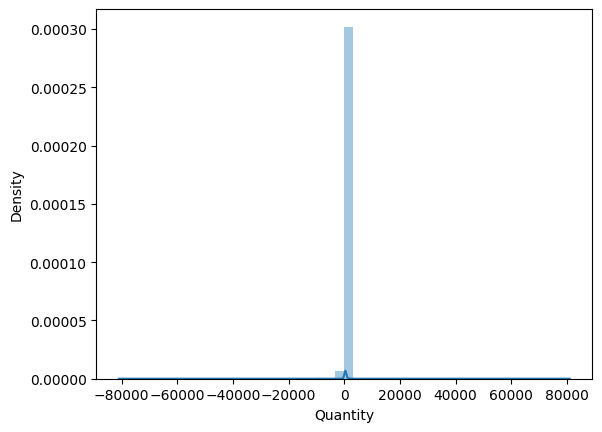

In [330]:
# distplot (Check the negative value and the distribution)
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use(['default'])

sns.distplot(df['Quantity'])

{'whiskers': [<matplotlib.lines.Line2D at 0x2cd096390>,
 'caps': [<matplotlib.lines.Line2D at 0x2cd0974d0>,
 'boxes': [<matplotlib.lines.Line2D at 0x2cd0ba7d0>],
 'medians': [<matplotlib.lines.Line2D at 0x2cd0803d0>],
 'fliers': [<matplotlib.lines.Line2D at 0x2cd080c10>],
 'means': []}

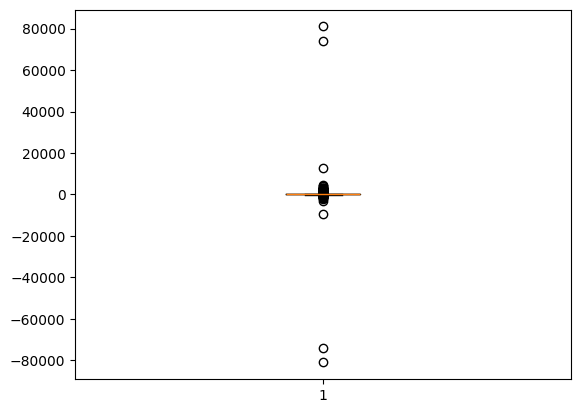

In [331]:
plt.boxplot(df["Quantity"])

<Axes: ylabel='Quantity'>

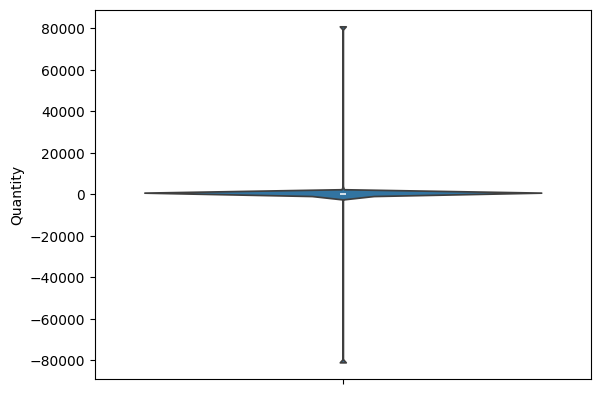

In [332]:
sns.violinplot(df["Quantity"])

#### Skewness 
- 0 ; Normal Distribution
- '> 0 ; Right Skewed (Mode < Median < Mean)
- < 0 ; Left Skewed (Mean < Median < Mode)

#### Kurtosis
- 3 ; Normal Distribution
- '> 3 ; Leptokurtic (Fat tails, high peak)
- < 3 ; platykurtic (thin tails, low peak)

In [333]:
print("skew : "+ str(df["Quantity"].skew()))
print("kurtosis : "+ str(df["Quantity"].kurtosis()))

skew : 0.18266266873582565
kurtosis : 94317.56367332725


In [334]:
# Check for negative data values
# Reassess domain knowledge (※ These might represent returned or recalled items)
df[df['Quantity']<0] 

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
141,C536379,D,Discount,-1,12/1/2010 9:41,27.50,14527.0,United Kingdom
154,C536383,35004C,SET OF 3 COLOURED FLYING DUCKS,-1,12/1/2010 9:49,4.65,15311.0,United Kingdom
235,C536391,22556,PLASTERS IN TIN CIRCUS PARADE,-12,12/1/2010 10:24,1.65,17548.0,United Kingdom
236,C536391,21984,PACK OF 12 PINK PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
237,C536391,21983,PACK OF 12 BLUE PAISLEY TISSUES,-24,12/1/2010 10:24,0.29,17548.0,United Kingdom
...,...,...,...,...,...,...,...,...
540449,C581490,23144,ZINC T-LIGHT HOLDER STARS SMALL,-11,12/9/2011 9:57,0.83,14397.0,United Kingdom
541541,C581499,M,Manual,-1,12/9/2011 10:28,224.69,15498.0,United Kingdom
541715,C581568,21258,VICTORIAN SEWING BOX LARGE,-5,12/9/2011 11:57,10.95,15311.0,United Kingdom
541716,C581569,84978,HANGING HEART JAR T-LIGHT HOLDER,-1,12/9/2011 11:58,1.25,17315.0,United Kingdom


In [335]:
# Drop Quantity < 0 
df = df[df['Quantity']>0]
df.describe()

,Quantity,UnitPrice,CustomerID
count,397924.000000,397924.000000,397924.000000
mean,13.021823,3.116174,15294.315171
std,180.420210,22.096788,1713.169877
min,1.000000,0.000000,12346.000000
25%,2.000000,1.250000,13969.000000
50%,6.000000,1.950000,15159.000000
75%,12.000000,3.750000,16795.000000
max,80995.000000,8142.750000,18287.000000


In [336]:
# Duplicated value
pd.Series(df.duplicated()).value_counts()

False    392732
True       5192
Name: count, dtype: int64

In [337]:
df[df.duplicated(keep=False)].sort_values(by=list(df.columns)).head(10)

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
494,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
517,536409,21866,UNION JACK FLAG LUGGAGE TAG,1,12/1/2010 11:45,1.25,17908.0,United Kingdom
485,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
539,536409,22111,SCOTTIE DOG HOT WATER BOTTLE,1,12/1/2010 11:45,4.95,17908.0,United Kingdom
489,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
527,536409,22866,HAND WARMER SCOTTY DOG DESIGN,1,12/1/2010 11:45,2.10,17908.0,United Kingdom
521,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
537,536409,22900,SET 2 TEA TOWELS I LOVE LONDON,1,12/1/2010 11:45,2.95,17908.0,United Kingdom
578,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom
598,536412,21448,12 DAISY PEGS IN WOOD BOX,1,12/1/2010 11:49,1.65,17920.0,United Kingdom


In [338]:
df = df.drop_duplicates(keep='first')
pd.Series(df.duplicated()).value_counts()

False    392732
Name: count, dtype: int64

In [339]:
df.shape

(392732, 8)

## 02. Data Readiness Check

```
* Assess whether the current data level is sufficient to solve the problem.
(1) Create target labels  
(2) Check target ratio  
(3) Determine analysis direction  
```

> **1. Genrate Target Label** 
```
* Define a repeat customer as any customer who purchases again in the following month after making a purchase in the current month (※ Target definition).
* Example: A customer who made a purchase in January 2011 and made another purchase in February 2011 is considered a repeat customer in the future.
```

> **2. Target Ratio** 
```
* Check the level of the target ratio created in step 1 and determine if it is sufficient to solve the problem.
```

> **3. Determine Analysis Direction** 
```
* Combine the results of steps 1 and 2 to decide the direction of the analysis.
  Example: If the target ratio is low, proceed with a specific segmentation group rather than all customers.
  Example: Expand the +1M purchase target to +2M/+3M in order to increase the target ratio.
```

### 1. Generate Target Label

In [340]:
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom


In [341]:
from datetime import datetime

df['date'] = df['InvoiceDate'].str.split(' ').str[0]
# "2023-01-15 10:45:00" --> ['2023-01-15', '10:45:00']

df['date'] = pd.to_datetime(df['date'])

df['bsym'] = df['date'].apply(lambda x: datetime.strftime(x, '%Y-%m'))
#strftime : formats a datetime object into a string according to a specific format. time --> string
# datetime.strptime : parses a string into a datetime object based on a given format. string--> time
df['CustomerID'] = df['CustomerID'].astype(str)
df.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,date,bsym
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,2010-12-01,2010-12
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,2010-12-01,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01,2010-12


In [342]:
# copy the org dataset
df_origin = df.copy()

In [343]:
# check the date range
df['date'].min(), df['date'].max()

(Timestamp('2010-12-01 00:00:00'), Timestamp('2011-12-09 00:00:00'))

In [344]:
# find the unqiue customerID based on 'bsym'ArithmeticErrord
df = df[['bsym', 'CustomerID']].drop_duplicates(keep= 'first')
df.head()

,bsym,CustomerID
0,2010-12,17850.0
9,2010-12,13047.0
26,2010-12,12583.0
46,2010-12,13748.0
65,2010-12,15100.0


In [345]:
# ▶ Target label  Sample Code (1-loop)
i = '2011-01'

df_left = df[df['bsym'] == i]
df_left

,bsym,CustomerID
42481,2011-01,13313.0
42505,2011-01,18097.0
42514,2011-01,16656.0
42518,2011-01,16875.0
42540,2011-01,13094.0
...,...,...
77437,2011-01,14006.0
77460,2011-01,13600.0
77483,2011-01,15058.0
77572,2011-01,17375.0


In [346]:
# ▶ Base year/month +1m
bsym_1m = (pd.to_datetime(i) + pd.DateOffset(months=1)).strftime('%Y-%m')
bsym_1m

'2011-02'

In [347]:
# find the list of customer who purchased in the t+ 1 month (the next month = repurchase in the next month)
df_right = pd.DataFrame(df[df['bsym'] == bsym_1m]['CustomerID'].unique()) 
df_right

,0
0,15240.0
1,14911.0
2,14496.0
3,17147.0
4,17675.0
...,...
753,15656.0
754,12811.0
755,16518.0
756,17165.0


In [348]:
df_right['target'] = 'Y'
df_right

,0,target
0,15240.0,Y
1,14911.0,Y
2,14496.0,Y
3,17147.0,Y
4,17675.0,Y
...,...,...
753,15656.0,Y
754,12811.0,Y
755,16518.0,Y
756,17165.0,Y


In [349]:
df_right.columns = ['CustomerID', 'target']
df_right

,CustomerID,target
0,15240.0,Y
1,14911.0,Y
2,14496.0,Y
3,17147.0,Y
4,17675.0,Y
...,...,...
753,15656.0,Y
754,12811.0,Y
755,16518.0,Y
756,17165.0,Y


In [350]:
df_left

,bsym,CustomerID
42481,2011-01,13313.0
42505,2011-01,18097.0
42514,2011-01,16656.0
42518,2011-01,16875.0
42540,2011-01,13094.0
...,...,...
77437,2011-01,14006.0
77460,2011-01,13600.0
77483,2011-01,15058.0
77572,2011-01,17375.0


In [351]:
df_merge = pd.merge(df_left, df_right, how='left')
df_merge['target'] = df_merge['target'].fillna('N')
df_merge

,bsym,CustomerID,target
0,2011-01,13313.0,N
1,2011-01,18097.0,N
2,2011-01,16656.0,Y
3,2011-01,16875.0,Y
4,2011-01,13094.0,Y
...,...,...,...
736,2011-01,14006.0,N
737,2011-01,13600.0,N
738,2011-01,15058.0,Y
739,2011-01,17375.0,N


In [352]:
df_merge['target'].value_counts()

target
N    479
Y    262
Name: count, dtype: int64

In [353]:
#find the target label for whole dataset

loop_list = list(df['bsym'].unique())
df_all = []

for i in loop_list :
  df_left = df[df['bsym'] == i]
  bsym_1m = (pd.to_datetime(i) + pd.DateOffset(months=1)).strftime('%Y-%m')
  df_right = pd.DataFrame(df[df['bsym'] == bsym_1m]['CustomerID'].unique())
  df_right['target'] = 1
  df_right.columns = ['CustomerID', 'target']
  df_merge = pd.merge(df_left, df_right, how='left')
  df_merge['target'] = df_merge['target'].fillna(0)

  df_all.append(df_merge)

df_all = pd.concat(df_all)

In [354]:
df.shape, df_all.shape

((13055, 2), (13055, 3))

In [355]:
df_all.head()

,bsym,CustomerID,target
0,2010-12,17850.0,0.0
1,2010-12,13047.0,0.0
2,2010-12,12583.0,1.0
3,2010-12,13748.0,0.0
4,2010-12,15100.0,1.0


In [356]:
df_all.tail()

,bsym,CustomerID,target
610,2011-12,12713.0,0.0
611,2011-12,17581.0,0.0
612,2011-12,15804.0,0.0
613,2011-12,13113.0,0.0
614,2011-12,12680.0,0.0


In [357]:
df

,bsym,CustomerID
0,2010-12,17850.0
9,2010-12,13047.0
26,2010-12,12583.0
46,2010-12,13748.0
65,2010-12,15100.0
...,...,...
541768,2011-12,12713.0
541806,2011-12,17581.0
541869,2011-12,15804.0
541890,2011-12,13113.0


In [358]:
df_all

,bsym,CustomerID,target
0,2010-12,17850.0,0.0
1,2010-12,13047.0,0.0
2,2010-12,12583.0,1.0
3,2010-12,13748.0,0.0
4,2010-12,15100.0,1.0
...,...,...,...
610,2011-12,12713.0,0.0
611,2011-12,17581.0,0.0
612,2011-12,15804.0,0.0
613,2011-12,13113.0,0.0


### 2. Check the Target Ratio

In [359]:
df_target = df_all.groupby('bsym')['target'].agg(['sum','count']).reset_index()
df_target.columns = ['bsym', 'Y', 'Total']
df_target['ratio'] = df_target['Y']/df_target['Total']
df_target

,bsym,Y,Total,ratio
0,2010-12,324.0,885,0.366102
1,2011-01,262.0,741,0.353576
2,2011-02,290.0,758,0.382586
3,2011-03,304.0,974,0.312115
4,2011-04,368.0,856,0.429907
5,2011-05,410.0,1056,0.388258
6,2011-06,365.0,991,0.368315
7,2011-07,388.0,949,0.408851
8,2011-08,425.0,935,0.454545
9,2011-09,489.0,1266,0.386256


In [360]:
# since our last dataset's bsym is 2011-12, we will drop last row
df_target = df_target.iloc[0:12, :]
df_target

,bsym,Y,Total,ratio
0,2010-12,324.0,885,0.366102
1,2011-01,262.0,741,0.353576
2,2011-02,290.0,758,0.382586
3,2011-03,304.0,974,0.312115
4,2011-04,368.0,856,0.429907
5,2011-05,410.0,1056,0.388258
6,2011-06,365.0,991,0.368315
7,2011-07,388.0,949,0.408851
8,2011-08,425.0,935,0.454545
9,2011-09,489.0,1266,0.386256


In [361]:
# total dataset's target ratio
df_target['Y'].sum()/df_target['Total'].sum()

0.3712218649517685

In [362]:
# drop 2011-12 data from the raw data
df_all = df_all[df_all['bsym'] != '2011-12']

In [363]:
df_all

,bsym,CustomerID,target
0,2010-12,17850.0,0.0
1,2010-12,13047.0,0.0
2,2010-12,12583.0,1.0
3,2010-12,13748.0,0.0
4,2010-12,15100.0,1.0
...,...,...,...
1660,2011-11,16915.0,0.0
1661,2011-11,16265.0,0.0
1662,2011-11,14085.0,1.0
1663,2011-11,12429.0,0.0


In [364]:
df_all['target'].sum()/len(df_all)

0.3712218649517685

## 03. Data Sampling(1)

### 1. Decision on Whether to Perform Sampling

* Performing sampling can facilitate effective data analysis and modeling:
```
  - Reduces data mart creation time
  - Shortens model training time
* Select an appropriate sampling method based on the current data context and perform sampling.

* Time Series Data
  (1) Up-sampling: Filling missing values when changing the frequency
  (2) Down-sampling: Applying mean(), max(), or min() based on the time window

* Non-Time Series Data
  (1) If the target data is too scarce (Class-Imbalanced) → Over-sampling
  (2) If there is too much data → Under-sampling
  ※ Perform stratified sampling during under-sampling
```

#### A. Over-sampling
```
* A representative over-sampling method is SMOTE (Synthetic Minority Over-sampling Technique).
* It generates new data for underrepresented classes using the k-NN (k-Nearest Neighbors) algorithm.
```

#### B. Under-sampling & Stratified Sampling
```
* Stratified Sampling: Dividing the population into homogeneous subgroups (strata) and selecting random samples from each group proportional to their size.
 - Proportional Stratified Sampling: Samples are selected in proportion to the population ratio of each stratum.

* Advantages:
 - Provides more reliable estimates than simple random sampling
 - Reduces cost and simplifies data analysis
 - Enables estimation for each stratum as an additional benefit
 
* Disadvantages:
 - Challenging to compile a list for large populations
 - Requires precise information about each stratum to divide the population appropriately
```

### 1. Time Series : Up-sampling

In [365]:
time_index = pd.date_range('2023-01-01', periods=3, freq='10S')
df_time = pd.DataFrame({'value' : [1, 2, 3]}, index = time_index)
df_time

/var/folders/h1/6sllxx6j0zb6l_hvj_9ys3qh0000gn/T/ipykernel_3253/2084609927.py:1: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  time_index = pd.date_range('2023-01-01', periods=3, freq='10S')


,value
2023-01-01 00:00:00,1
2023-01-01 00:00:10,2
2023-01-01 00:00:20,3


In [366]:
#Up-sampling(5S)
df_upsample = df_time.resample('5S').mean()
df_upsample

/var/folders/h1/6sllxx6j0zb6l_hvj_9ys3qh0000gn/T/ipykernel_3253/1335765011.py:2: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_upsample = df_time.resample('5S').mean()


,value
2023-01-01 00:00:00,1.0
2023-01-01 00:00:05,NaN
2023-01-01 00:00:10,2.0
2023-01-01 00:00:15,NaN
2023-01-01 00:00:20,3.0


In [367]:
# ▶ ffill
# df_upsample.fillna(method='ffill')

# ▶ bfill
# df_upsample.fillna(method='bfill')

# ▶ fill(0)
# df_upsample.fillna(0)

# ▶ mean()
# df_upsample.fillna(df_upsample.mean())

# ▶ linear interpolation
df_upsample.interpolate()

,value
2023-01-01 00:00:00,1.0
2023-01-01 00:00:05,1.5
2023-01-01 00:00:10,2.0
2023-01-01 00:00:15,2.5
2023-01-01 00:00:20,3.0


### 2. Time Series : Down-sampling

In [368]:
df_upsample.resample('10S').mean()

/var/folders/h1/6sllxx6j0zb6l_hvj_9ys3qh0000gn/T/ipykernel_3253/209742934.py:1: FutureWarning: 'S' is deprecated and will be removed in a future version, please use 's' instead.
  df_upsample.resample('10S').mean()


,value
2023-01-01 00:00:00,1.0
2023-01-01 00:00:10,2.0
2023-01-01 00:00:20,3.0


### 3. Non-Time Series : SMOTE(Over-sampling)

In [369]:
# ▶ SMOTE 
df_all.head()

,bsym,CustomerID,target
0,2010-12,17850.0,0.0
1,2010-12,13047.0,0.0
2,2010-12,12583.0,1.0
3,2010-12,13748.0,0.0
4,2010-12,15100.0,1.0


In [370]:
df_all['target'].sum()/len(df_all)

0.3712218649517685

In [371]:
df_all['target'].value_counts()

target
0.0    7822
1.0    4618
Name: count, dtype: int64

In [372]:
# data split for sampling
X = df_all.drop(['bsym', 'target'], axis=1)
Y = df_all['target']

In [373]:
# SMOTE Over-sampling
from imblearn.over_sampling import SMOTE

smote = SMOTE(random_state = 123)
X_over, y_over = smote.fit_resample(X,Y)
print("SMOTE 적용 전 학습용 피처/레이블 데이터 세트 : ", X.shape, Y.shape)
print('SMOTE 적용 후 학습용 피처/레이블 데이터 세트 :', X_over.shape, y_over.shape)
print('SMOTE 적용 전 값의 분포 :\n',pd.Series(Y).value_counts() )
print('SMOTE 적용 후 값의 분포 :\n',pd.Series(y_over).value_counts() )

SMOTE 적용 전 학습용 피처/레이블 데이터 세트 :  (12440, 1) (12440,)
SMOTE 적용 후 학습용 피처/레이블 데이터 세트 : (15644, 1) (15644,)
SMOTE 적용 전 값의 분포 :
 target
0.0    7822
1.0    4618
Name: count, dtype: int64
SMOTE 적용 후 값의 분포 :
 target
0.0    7822
1.0    7822
Name: count, dtype: int64


### 4. Non-Time Series : Stratified Sampling

In [374]:
# Stratified sampling
df_all.head()

,bsym,CustomerID,target
0,2010-12,17850.0,0.0
1,2010-12,13047.0,0.0
2,2010-12,12583.0,1.0
3,2010-12,13748.0,0.0
4,2010-12,15100.0,1.0


In [375]:
df_target

,bsym,Y,Total,ratio
0,2010-12,324.0,885,0.366102
1,2011-01,262.0,741,0.353576
2,2011-02,290.0,758,0.382586
3,2011-03,304.0,974,0.312115
4,2011-04,368.0,856,0.429907
5,2011-05,410.0,1056,0.388258
6,2011-06,365.0,991,0.368315
7,2011-07,388.0,949,0.408851
8,2011-08,425.0,935,0.454545
9,2011-09,489.0,1266,0.386256


In [376]:
# target_ratio / total_ratio col 
# find the ratio of month
df_target['total_ratio'] = df_target['Total'] / df_target['Total'].sum()
df_target.columns = ['bsym', 'y', 'total_cnt', 'target_ratio', 'total_ratio']
df_target

/var/folders/h1/6sllxx6j0zb6l_hvj_9ys3qh0000gn/T/ipykernel_3253/259240365.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_target['total_ratio'] = df_target['Total'] / df_target['Total'].sum()


,bsym,y,total_cnt,target_ratio,total_ratio
0,2010-12,324.0,885,0.366102,0.071141
1,2011-01,262.0,741,0.353576,0.059566
2,2011-02,290.0,758,0.382586,0.060932
3,2011-03,304.0,974,0.312115,0.078296
4,2011-04,368.0,856,0.429907,0.068810
5,2011-05,410.0,1056,0.388258,0.084887
6,2011-06,365.0,991,0.368315,0.079662
7,2011-07,388.0,949,0.408851,0.076286
8,2011-08,425.0,935,0.454545,0.075161
9,2011-09,489.0,1266,0.386256,0.101768


In [377]:
df_target['total_cnt'].sum()

12440

In [378]:
# # ▶ Total(sum)행 추가
# df_target = df_target.append({'bsym': 'total'
#           , 'y': df_target['y'].sum()
#           , 'total_cnt': df_target['total_cnt'].sum()
#           , 'target_ratio' : df_target['y'].sum() / df_target['total_cnt'].sum()
#           , 'total_ratio' : 1}, ignore_index=True)
# df_target

In [379]:
# 30% statified
len(df_all) * 0.3

3732.0

In [380]:
# ▶ 30% sampling을 한다고 가정했을 때, 각 월 별 비중과 동일하게 Random sampling 하는 것이 중요 (비례층화추출)
# ▶ sample_n : 비례층화추출을 위한 월 별 추출 개수
df_target['sample_n_total'] = len(df_all) * 0.3 # 전체 12440 * 30% = 3732개 즉 다 합처서 3732개 뽑는 거야. 
df_target['sample_n'] = df_target['sample_n_total'] * df_target['total_ratio'] 
df_target['sample_n'] = df_target['sample_n'].astype(int)
df_target

/var/folders/h1/6sllxx6j0zb6l_hvj_9ys3qh0000gn/T/ipykernel_3253/1162664665.py:3: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_target['sample_n_total'] = len(df_all) * 0.3 # 전체 12440 * 30% = 3732개 즉 다 합처서 3732개 뽑는 거야.
/var/folders/h1/6sllxx6j0zb6l_hvj_9ys3qh0000gn/T/ipykernel_3253/1162664665.py:4: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_target['sample_n'] = df_target['sample_n_total'] * df_target['total_ratio']
/var/folders/h1/6sllxx6j0zb6l_hvj_9ys3qh0000gn/T/ipykernel_3253/1162664665.py:5: Sett

,bsym,y,total_cnt,target_ratio,total_ratio,sample_n_total,sample_n
0,2010-12,324.0,885,0.366102,0.071141,3732.0,265
1,2011-01,262.0,741,0.353576,0.059566,3732.0,222
2,2011-02,290.0,758,0.382586,0.060932,3732.0,227
3,2011-03,304.0,974,0.312115,0.078296,3732.0,292
4,2011-04,368.0,856,0.429907,0.068810,3732.0,256
5,2011-05,410.0,1056,0.388258,0.084887,3732.0,316
6,2011-06,365.0,991,0.368315,0.079662,3732.0,297
7,2011-07,388.0,949,0.408851,0.076286,3732.0,284
8,2011-08,425.0,935,0.454545,0.075161,3732.0,280
9,2011-09,489.0,1266,0.386256,0.101768,3732.0,379


In [381]:
rnd_sate = 1234

df_all_00 = df_all[df_all['bsym'] == '2010-12'].sample(n=265, random_state = rnd_sate)
df_all_01 = df_all[df_all['bsym'] == '2011-01'].sample(n=222, random_state = rnd_sate)
df_all_02 = df_all[df_all['bsym'] == '2011-02'].sample(n=227, random_state = rnd_sate)
df_all_03 = df_all[df_all['bsym'] == '2011-03'].sample(n=292, random_state = rnd_sate)
df_all_04 = df_all[df_all['bsym'] == '2011-04'].sample(n=256, random_state = rnd_sate)
df_all_05 = df_all[df_all['bsym'] == '2011-05'].sample(n=316, random_state = rnd_sate)
df_all_06 = df_all[df_all['bsym'] == '2011-06'].sample(n=297, random_state = rnd_sate)
df_all_07 = df_all[df_all['bsym'] == '2011-07'].sample(n=284, random_state = rnd_sate)
df_all_08 = df_all[df_all['bsym'] == '2011-08'].sample(n=280, random_state = rnd_sate)
df_all_09 = df_all[df_all['bsym'] == '2011-09'].sample(n=379, random_state = rnd_sate)
df_all_10 = df_all[df_all['bsym'] == '2011-10'].sample(n=409, random_state = rnd_sate)
df_all_11 = df_all[df_all['bsym'] == '2011-11'].sample(n=499, random_state = rnd_sate)


In [382]:
df_all_00

,bsym,CustomerID,target
297,2010-12,12763.0,0.0
375,2010-12,17091.0,1.0
571,2010-12,13969.0,1.0
603,2010-12,16727.0,0.0
21,2010-12,13448.0,0.0
...,...,...,...
63,2010-12,14594.0,0.0
28,2010-12,17908.0,0.0
615,2010-12,16923.0,1.0
676,2010-12,13211.0,0.0


In [383]:
df_all_sample = pd.concat([df_all_00, df_all_01, df_all_02, df_all_03, df_all_04, df_all_05, df_all_06, df_all_07, df_all_08, df_all_09, df_all_10, df_all_11], axis=0)
df_all_sample

,bsym,CustomerID,target
297,2010-12,12763.0,0.0
375,2010-12,17091.0,1.0
571,2010-12,13969.0,1.0
603,2010-12,16727.0,0.0
21,2010-12,13448.0,0.0
...,...,...,...
803,2011-11,15021.0,1.0
793,2011-11,13892.0,0.0
579,2011-11,14836.0,0.0
122,2011-11,15743.0,0.0


In [384]:
# Traget_ratio_samnple(mosu)
df_all_sample_temp = df_all_sample.groupby(['bsym'])['target'].agg(['sum', 'count']).reset_index()
df_all_sample_temp['target_ratio'] = df_all_sample_temp['sum'] / df_all_sample_temp['count']
df_all_sample_temp['target_ratio_mosu'] = df_target['target_ratio']

df_all_sample_temp.style.bar(subset=['target_ratio','target_ratio_mosu'], align='zero', vmin=0, vmax=0.8)

,bsym,sum,count,target_ratio,target_ratio_mosu
0,2010-12,98.000000,265,0.369811,0.366102
1,2011-01,80.000000,222,0.360360,0.353576
2,2011-02,97.000000,227,0.427313,0.382586
3,2011-03,89.000000,292,0.304795,0.312115
4,2011-04,112.000000,256,0.437500,0.429907
5,2011-05,123.000000,316,0.389241,0.388258
6,2011-06,111.000000,297,0.373737,0.368315
7,2011-07,123.000000,284,0.433099,0.408851
8,2011-08,137.000000,280,0.489286,0.454545
9,2011-09,152.000000,379,0.401055,0.386256


In [385]:
#Target ratio (※ mosu 37%)
df_all_sample_temp['sum'].sum() / df_all_sample_temp['count'].sum()

0.38539989264626945

In [386]:
df_all_sample.shape

(3726, 3)

In [387]:
df_all_sample

,bsym,CustomerID,target
297,2010-12,12763.0,0.0
375,2010-12,17091.0,1.0
571,2010-12,13969.0,1.0
603,2010-12,16727.0,0.0
21,2010-12,13448.0,0.0
...,...,...,...
803,2011-11,15021.0,1.0
793,2011-11,13892.0,0.0
579,2011-11,14836.0,0.0
122,2011-11,15743.0,0.0


# III. Data Mart and Feature Engineering 

## 01. Generate Data Mart 

```
* Customer IDs based on monthly criteria have been extracted after sampling.  
* All preparations for building the data mart have been completed.  
* Hypotheses have been established, and various variable categories and lists corresponding to the hypotheses have been created.  
* Designing a rich data mart is essential for achieving good model performance and enabling diverse interpretations.  

```

```
#### Theory 1. The probability of repurchase in the following month will vary depending on the current month's purchase amount($). 

#### Theory 2. The probability of repurchase in the following month will vary depending on the current month;s purchase count and quantity. 

#### Theory 3. The probability of repurchase will vary depending on the country. 

```

## 02. EDA & Develop Data Mart


```
* Based on the Data Mart, extract the features

```

In [388]:
df_origin.head()

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,date,bsym
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,2010-12-01,2010-12
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01,2010-12
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,2010-12-01,2010-12
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01,2010-12
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01,2010-12


### Prepare Mart

In [389]:
df_all_sample.head()

,bsym,CustomerID,target
297,2010-12,12763.0,0.0
375,2010-12,17091.0,1.0
571,2010-12,13969.0,1.0
603,2010-12,16727.0,0.0
21,2010-12,13448.0,0.0


In [390]:
df_all_sample.shape

(3726, 3)

In [391]:
#Generating a unique Key for Sampling from the Origin Data (1)
df_origin['sample_key'] = df_origin['bsym'].astype(str) + df_origin['CustomerID'].astype(str)
df_origin.head()
#

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,date,bsym,sample_key
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,12/1/2010 8:26,2.55,17850.0,United Kingdom,2010-12-01,2010-12,2010-1217850.0
1,536365,71053,WHITE METAL LANTERN,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01,2010-12,2010-1217850.0
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,12/1/2010 8:26,2.75,17850.0,United Kingdom,2010-12-01,2010-12,2010-1217850.0
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01,2010-12,2010-1217850.0
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,12/1/2010 8:26,3.39,17850.0,United Kingdom,2010-12-01,2010-12,2010-1217850.0


In [392]:
df_all_sample['sample_key'] = df_all_sample['bsym'].astype(str) + df_all_sample['CustomerID'].astype(str)
df_all_sample.head()

,bsym,CustomerID,target,sample_key
297,2010-12,12763.0,0.0,2010-1212763.0
375,2010-12,17091.0,1.0,2010-1217091.0
571,2010-12,13969.0,1.0,2010-1213969.0
603,2010-12,16727.0,0.0,2010-1216727.0
21,2010-12,13448.0,0.0,2010-1213448.0


In [393]:
# sampling 된 CustomerID만 추출 
df_origin_sample = df_origin[df_origin['sample_key'].isin(df_all_sample['sample_key'])]

# amt col 생성
df_origin_sample['amt'] = df_origin_sample['UnitPrice'] * df_origin_sample['Quantity']
df_origin_sample.head()

/var/folders/h1/6sllxx6j0zb6l_hvj_9ys3qh0000gn/T/ipykernel_3253/4013505928.py:5: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df_origin_sample['amt'] = df_origin_sample['UnitPrice'] * df_origin_sample['Quantity']


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,date,bsym,sample_key,amt
105,536380,22961,JAM MAKING SET PRINTED,24,12/1/2010 9:41,1.45,17809.0,United Kingdom,2010-12-01,2010-12,2010-1217809.0,34.80
106,536381,22139,RETROSPOT TEA SET CERAMIC 11 PC,23,12/1/2010 9:41,4.25,15311.0,United Kingdom,2010-12-01,2010-12,2010-1215311.0,97.75
107,536381,84854,GIRLY PINK TOOL SET,5,12/1/2010 9:41,4.95,15311.0,United Kingdom,2010-12-01,2010-12,2010-1215311.0,24.75
108,536381,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,10,12/1/2010 9:41,1.95,15311.0,United Kingdom,2010-12-01,2010-12,2010-1215311.0,19.50
109,536381,82567,"AIRLINE LOUNGE,METAL SIGN",2,12/1/2010 9:41,2.10,15311.0,United Kingdom,2010-12-01,2010-12,2010-1215311.0,4.20


In [394]:
df_origin.shape, df_origin_sample.shape

((392732, 11), (112421, 12))

### Extract Data Mart

In [395]:
df_origin_sample

,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country,date,bsym,sample_key,amt
105,536380,22961,JAM MAKING SET PRINTED,24,12/1/2010 9:41,1.45,17809.0,United Kingdom,2010-12-01,2010-12,2010-1217809.0,34.80
106,536381,22139,RETROSPOT TEA SET CERAMIC 11 PC,23,12/1/2010 9:41,4.25,15311.0,United Kingdom,2010-12-01,2010-12,2010-1215311.0,97.75
107,536381,84854,GIRLY PINK TOOL SET,5,12/1/2010 9:41,4.95,15311.0,United Kingdom,2010-12-01,2010-12,2010-1215311.0,24.75
108,536381,22411,JUMBO SHOPPER VINTAGE RED PAISLEY,10,12/1/2010 9:41,1.95,15311.0,United Kingdom,2010-12-01,2010-12,2010-1215311.0,19.50
109,536381,82567,"AIRLINE LOUNGE,METAL SIGN",2,12/1/2010 9:41,2.10,15311.0,United Kingdom,2010-12-01,2010-12,2010-1215311.0,4.20
...,...,...,...,...,...,...,...,...,...,...,...,...
516165,579872,21914,BLUE HARMONICA IN BOX,24,11/30/2011 16:54,1.25,14085.0,United Kingdom,2011-11-30,2011-11,2011-1114085.0,30.00
516166,579872,23275,SET OF 3 HANGING OWLS OLLIE BEAK,12,11/30/2011 16:54,1.25,14085.0,United Kingdom,2011-11-30,2011-11,2011-1114085.0,15.00
516167,579872,17003,BROCADE RING PURSE,72,11/30/2011 16:54,0.39,14085.0,United Kingdom,2011-11-30,2011-11,2011-1114085.0,28.08
516168,579872,23229,VINTAGE DONKEY TAIL GAME,10,11/30/2011 16:54,3.75,14085.0,United Kingdom,2011-11-30,2011-11,2011-1114085.0,37.50


In [396]:
# total_amt
df_mart = df_origin_sample.groupby(['bsym', 'CustomerID'])['amt'].agg(total_amt=('sum')).reset_index()
df_mart

,bsym,CustomerID,total_amt
0,2010-12,12370.0,1864.27
1,2010-12,12383.0,600.72
2,2010-12,12395.0,679.92
3,2010-12,12417.0,291.34
4,2010-12,12481.0,791.34
...,...,...,...
3721,2011-11,18188.0,392.76
3722,2011-11,18205.0,291.60
3723,2011-11,18209.0,139.10
3724,2011-11,18230.0,663.84


In [397]:
# max_amt, min_amt
# pd.DataFrame(df_origin_sample.groupby(['bsym', 'CustomerID', 'InvoiceNo'])['amt'].agg(amt = ('sum')).reset_index()).groupby(['bsym', 'CustomerID'])['amt'].agg(max_amt = ('max')).reset_index()
df_mart[['max_amt', 'min_amt']] = pd.DataFrame(df_origin_sample.groupby(['bsym', 'CustomerID', 'InvoiceNo'])['amt'].agg(amt = ('sum')).reset_index()).groupby(['bsym', 'CustomerID'])['amt'].agg(max_amt = ('max'), min_amt = ('min')).reset_index()[['max_amt', 'min_amt']]
df_mart

,bsym,CustomerID,total_amt,max_amt,min_amt
0,2010-12,12370.0,1864.27,1587.07,277.20
1,2010-12,12383.0,600.72,600.72,600.72
2,2010-12,12395.0,679.92,346.10,333.82
3,2010-12,12417.0,291.34,291.34,291.34
4,2010-12,12481.0,791.34,631.96,159.38
...,...,...,...,...,...
3721,2011-11,18188.0,392.76,392.76,392.76
3722,2011-11,18205.0,291.60,291.60,291.60
3723,2011-11,18209.0,139.10,139.10,139.10
3724,2011-11,18230.0,663.84,343.80,320.04


In [398]:
#total_cnt
df_mart['total_cnt'] = pd.DataFrame(df_origin_sample.groupby(['bsym', 'CustomerID'])['InvoiceNo'].agg(total_cnt = ('nunique'))).reset_index()['total_cnt']
df_mart

,bsym,CustomerID,total_amt,max_amt,min_amt,total_cnt
0,2010-12,12370.0,1864.27,1587.07,277.20,2
1,2010-12,12383.0,600.72,600.72,600.72,1
2,2010-12,12395.0,679.92,346.10,333.82,2
3,2010-12,12417.0,291.34,291.34,291.34,1
4,2010-12,12481.0,791.34,631.96,159.38,2
...,...,...,...,...,...,...
3721,2011-11,18188.0,392.76,392.76,392.76,1
3722,2011-11,18205.0,291.60,291.60,291.60,1
3723,2011-11,18209.0,139.10,139.10,139.10,1
3724,2011-11,18230.0,663.84,343.80,320.04,2


In [399]:
# max_cnt, min_cnt
df_mart[['max_cnt', 'min_cnt']] = pd.DataFrame(df_origin_sample.groupby(['bsym', 'CustomerID', 'InvoiceNo'])['StockCode'].agg(stock_cnt = 'nunique').reset_index()).groupby(['bsym', 'CustomerID'])['stock_cnt'].agg(max_cnt = ('max'), min_cnt = ('min')).reset_index()[['max_cnt', 'min_cnt']]
df_mart

,bsym,CustomerID,total_amt,max_amt,min_amt,total_cnt,max_cnt,min_cnt
0,2010-12,12370.0,1864.27,1587.07,277.20,2,82,8
1,2010-12,12383.0,600.72,600.72,600.72,1,37,37
2,2010-12,12395.0,679.92,346.10,333.82,2,19,12
3,2010-12,12417.0,291.34,291.34,291.34,1,11,11
4,2010-12,12481.0,791.34,631.96,159.38,2,12,10
...,...,...,...,...,...,...,...,...
3721,2011-11,18188.0,392.76,392.76,392.76,1,13,13
3722,2011-11,18205.0,291.60,291.60,291.60,1,17,17
3723,2011-11,18209.0,139.10,139.10,139.10,1,8,8
3724,2011-11,18230.0,663.84,343.80,320.04,2,11,6


In [400]:
#total_qty, max_qty, min_qty
df_mart[['total_qty', 'max_qty', 'min_qty']] = df_origin_sample.groupby(['bsym', 'CustomerID'])['Quantity'].agg(total_qty = 'sum', max_qty = 'max', min_qty = 'min').reset_index()[['total_qty', 'max_qty', 'min_qty']]
df_mart

,bsym,CustomerID,total_amt,max_amt,min_amt,total_cnt,max_cnt,min_cnt,total_qty,max_qty,min_qty
0,2010-12,12370.0,1864.27,1587.07,277.20,2,82,8,967,96,1
1,2010-12,12383.0,600.72,600.72,600.72,1,37,37,754,100,3
2,2010-12,12395.0,679.92,346.10,333.82,2,19,12,753,120,1
3,2010-12,12417.0,291.34,291.34,291.34,1,11,11,60,16,2
4,2010-12,12481.0,791.34,631.96,159.38,2,12,10,319,48,1
...,...,...,...,...,...,...,...,...,...,...,...
3721,2011-11,18188.0,392.76,392.76,392.76,1,13,13,268,60,4
3722,2011-11,18205.0,291.60,291.60,291.60,1,17,17,116,24,2
3723,2011-11,18209.0,139.10,139.10,139.10,1,8,8,58,12,3
3724,2011-11,18230.0,663.84,343.80,320.04,2,11,6,286,48,4


In [401]:
# country
df_mart['Country'] = df_origin_sample.groupby(['bsym', 'CustomerID'])['Country'].agg(country = 'first').reset_index()['country']
df_mart

,bsym,CustomerID,total_amt,max_amt,min_amt,total_cnt,max_cnt,min_cnt,total_qty,max_qty,min_qty,Country
0,2010-12,12370.0,1864.27,1587.07,277.20,2,82,8,967,96,1,Cyprus
1,2010-12,12383.0,600.72,600.72,600.72,1,37,37,754,100,3,Belgium
2,2010-12,12395.0,679.92,346.10,333.82,2,19,12,753,120,1,Belgium
3,2010-12,12417.0,291.34,291.34,291.34,1,11,11,60,16,2,Belgium
4,2010-12,12481.0,791.34,631.96,159.38,2,12,10,319,48,1,Germany
...,...,...,...,...,...,...,...,...,...,...,...,...
3721,2011-11,18188.0,392.76,392.76,392.76,1,13,13,268,60,4,United Kingdom
3722,2011-11,18205.0,291.60,291.60,291.60,1,17,17,116,24,2,United Kingdom
3723,2011-11,18209.0,139.10,139.10,139.10,1,8,8,58,12,3,United Kingdom
3724,2011-11,18230.0,663.84,343.80,320.04,2,11,6,286,48,4,United Kingdom


In [402]:
#target join
df_mart = pd.merge(df_mart, df_all_sample[['bsym', 'CustomerID', 'target']], how='left', on=['bsym', 'CustomerID'])
df_mart

,bsym,CustomerID,total_amt,max_amt,min_amt,total_cnt,max_cnt,min_cnt,total_qty,max_qty,min_qty,Country,target
0,2010-12,12370.0,1864.27,1587.07,277.20,2,82,8,967,96,1,Cyprus,0.0
1,2010-12,12383.0,600.72,600.72,600.72,1,37,37,754,100,3,Belgium,1.0
2,2010-12,12395.0,679.92,346.10,333.82,2,19,12,753,120,1,Belgium,0.0
3,2010-12,12417.0,291.34,291.34,291.34,1,11,11,60,16,2,Belgium,1.0
4,2010-12,12481.0,791.34,631.96,159.38,2,12,10,319,48,1,Germany,1.0
...,...,...,...,...,...,...,...,...,...,...,...,...,...
3721,2011-11,18188.0,392.76,392.76,392.76,1,13,13,268,60,4,United Kingdom,0.0
3722,2011-11,18205.0,291.60,291.60,291.60,1,17,17,116,24,2,United Kingdom,0.0
3723,2011-11,18209.0,139.10,139.10,139.10,1,8,8,58,12,3,United Kingdom,0.0
3724,2011-11,18230.0,663.84,343.80,320.04,2,11,6,286,48,4,United Kingdom,0.0


In [403]:
#Data set
df_mart.shape

(3726, 13)

## 03. Numerical Feature Engineering

* Regression: Use correlation analysis to identify significant features.
* Classification: Use binning to group data and examine relationships with the target variable.


> ### **└ Regression (corr)** 

In [404]:
df_mart.head()

,bsym,CustomerID,total_amt,max_amt,min_amt,total_cnt,max_cnt,min_cnt,total_qty,max_qty,min_qty,Country,target
0,2010-12,12370.0,1864.27,1587.07,277.20,2,82,8,967,96,1,Cyprus,0.0
1,2010-12,12383.0,600.72,600.72,600.72,1,37,37,754,100,3,Belgium,1.0
2,2010-12,12395.0,679.92,346.10,333.82,2,19,12,753,120,1,Belgium,0.0
3,2010-12,12417.0,291.34,291.34,291.34,1,11,11,60,16,2,Belgium,1.0
4,2010-12,12481.0,791.34,631.96,159.38,2,12,10,319,48,1,Germany,1.0


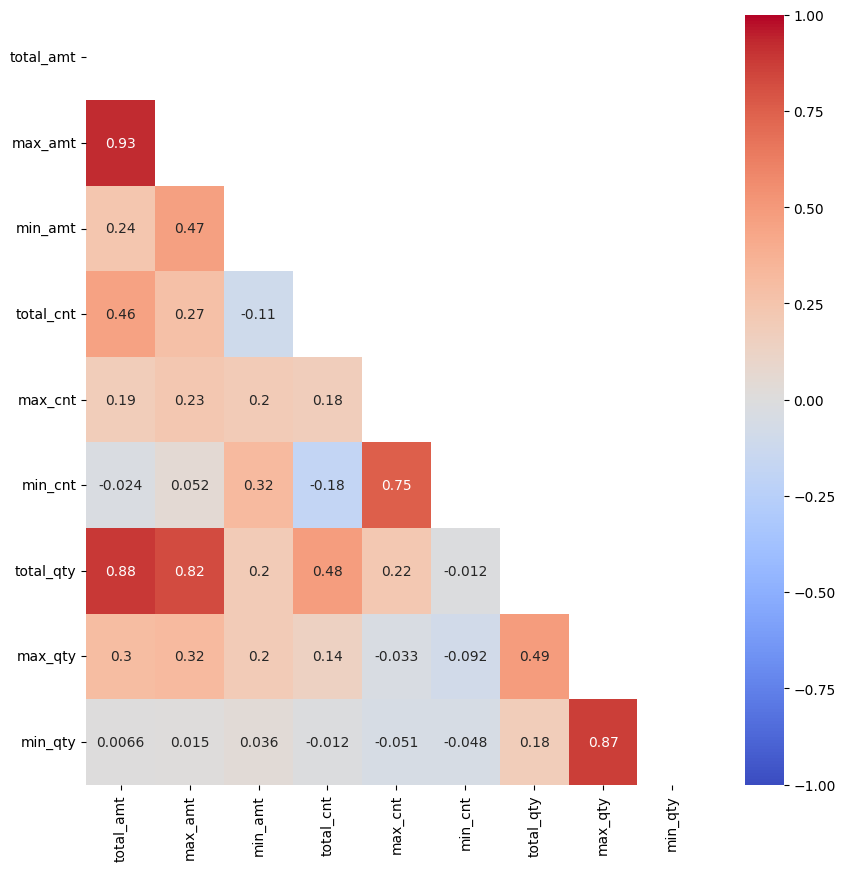

In [405]:
# Heatmap
import seaborn as sns
#correlation
df_pair = df_mart[['total_amt', 'max_amt', 'min_amt', 'total_cnt','max_cnt', 'min_cnt', 'total_qty', 'max_qty', 'min_qty']]
# drop duplicated 
mask = np.triu(np.ones_like(df_pair.corr()))
sns.heatmap(df_pair.corr(), vmin = -1, vmax = +1, annot = True, cmap = 'coolwarm', mask = mask);
plt.gcf().set_size_inches(10, 10)

> ### **└ Classification (IV)** 

> **IV (Information Value)**

IV는 데이터분석에서 변수의 예측력을 측정하기 위해 사용하는 지표. 

- 주로 이진 분류 문제에서 Feature가 Target과 얼마나 강하게 관련 있는지 평가. 

- IV는 각 범주(category)에서 좋은(good) 클래스와 나쁜(bad) 클래스의 비율 차이를 계산하여, 특정 변수가 목표(target) 변수의 예측력을 얼마나 기여하는지를 정량적으로 나타냄

IV의 계산 과정
1. 변수의 범주화(Binning):
    - 연속형 변수(예: 나이, 소득)라면 적절한 범위로 나누어 범주화(binning)합니다.
    - 범주형 변수라면 고유 값을 기준으로 각 값을 하나의 범주로 봅니다.
2. 각 범주의 good과 bad 개수 계산:
    - 종속 변수(Target)가 이진 변수(예: 0=연체 X, 1=연체 O)라고 가정합니다.
    - 각 범주에서 good(예: 0)의 수와 bad(예: 1)의 수를 계산합니다.
3. 각 법주의 비율 계산 :
    - Good % = 범주의 good 수 / 전체 good 수
    - Bad % = 범주의 bad 수 / 전체 bad 수
4. Weight of Evidence (WOE, 증거 가중치) 계산 : 
    - ln자연로그
    - Good% 또는 Bad%가 0이면 계산이 불가능하므로, 일반적으로 0 대신 작은 값을 대체합니다(예: 0.0001).
5. IV 값 계산
    - IV는 모든 범주의 WoE와 Good% - Bad%의 곱을 더한 값입니다


예를들어 age binning
전체 Good 수 : 500 / 전체 Bad 수 : 200
1. 20's Good : 200 Bad : 50 /
 Good % : 0.4 Bad % : 0.25
2. 30's Good : 200 Bad : 100 / Good % : 0.4 Bad % : 0.5
3. 40's Good : 100 Bad : 50 / Good % : 0.4 Bad % : 0.25

WOE계산
- Weight of Evidence (WoE) 계산에서 자연로그(ln)를 사용하는 이유는 데이터의 **Good%**와 Bad% 비율 간의 비율 차이를 효과적으로 비교하고, 이를 모델링이나 변수의 예측력 평가에 적합한 형태로 변환하기 위해서입니다.
- 20's = ln(0.4/0.25) = 0.470

IV Score 
- (Good% - Bad%) × WoE
- 20's : (0.40-.0.25) x 0.470 = 0.071


이렇게 모든 bin들의 IV score 합산
- IV=0.071+0.022+0.011=0.104
- 약한 예측력. 0.5 이상이어야함. 


In [406]:
# Binning
total_amt_quantile  = df_mart['total_amt'].quantile(q=list(np.arange(0.05,1,0.05)), interpolation = 'nearest') 
total_amt_quantile

0.05      98.70
0.10     123.13
0.15     150.75
0.20     178.35
0.25     208.56
0.30     240.60
0.35     282.66
0.40     304.34
0.45     319.97
0.50     347.49
0.55     380.40
0.60     421.90
0.65     472.13
0.70     540.01
0.75     615.85
0.80     711.80
0.85     841.50
0.90    1075.18
0.95    1766.32
Name: total_amt, dtype: float64

In [407]:
df_mart['total_amt_grp'] = 0

# Divide into 3
for i in  range(len(df_mart['total_amt'])) :
  if df_mart.loc[i, "total_amt"] <= total_amt_quantile.iloc[7] : # 40% 
    df_mart.loc[i, 'total_amt_grp'] = 1
  elif df_mart.loc[i, "total_amt"] <= total_amt_quantile.iloc[14] : # 75%
    df_mart.loc[i, 'total_amt_grp'] = 2
  else : df_mart.loc[i, 'total_amt_grp'] = 3

In [408]:
df_mart.groupby('total_amt_grp')['target'].agg(['sum', 'count'])
# sum = Target:1
# For group 3, 50%+ are target:1, they repurchase

,sum,count
total_amt_grp,,
1,422.0,1491
2,522.0,1304
3,492.0,931


In [409]:
df_mart

,bsym,CustomerID,total_amt,max_amt,min_amt,total_cnt,max_cnt,min_cnt,total_qty,max_qty,min_qty,Country,target,total_amt_grp
0,2010-12,12370.0,1864.27,1587.07,277.20,2,82,8,967,96,1,Cyprus,0.0,3
1,2010-12,12383.0,600.72,600.72,600.72,1,37,37,754,100,3,Belgium,1.0,2
2,2010-12,12395.0,679.92,346.10,333.82,2,19,12,753,120,1,Belgium,0.0,3
3,2010-12,12417.0,291.34,291.34,291.34,1,11,11,60,16,2,Belgium,1.0,1
4,2010-12,12481.0,791.34,631.96,159.38,2,12,10,319,48,1,Germany,1.0,3
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
3721,2011-11,18188.0,392.76,392.76,392.76,1,13,13,268,60,4,United Kingdom,0.0,2
3722,2011-11,18205.0,291.60,291.60,291.60,1,17,17,116,24,2,United Kingdom,0.0,1
3723,2011-11,18209.0,139.10,139.10,139.10,1,8,8,58,12,3,United Kingdom,0.0,1
3724,2011-11,18230.0,663.84,343.80,320.04,2,11,6,286,48,4,United Kingdom,0.0,3


In [410]:
# non target labeling
df_mart['n_target'] = np.where(df_mart['target']==0,1,0)

# target, non-target count
iv = df_mart.groupby('total_amt_grp')[['target','n_target']].sum().reset_index()

# good_pct / bad_pct 
iv['good_pct'] = iv['target'] / iv['target'].sum()
iv['bad_pct'] = iv['n_target'] / iv['n_target'].sum()

# t_ratio
iv['t_ratio'] = iv['target'] / (iv['target'] + iv['n_target'])

iv

,total_amt_grp,target,n_target,good_pct,bad_pct,t_ratio
0,1,422.0,1069,0.293872,0.466812,0.283032
1,2,522.0,782,0.363510,0.341485,0.400307
2,3,492.0,439,0.342618,0.191703,0.528464


In [411]:
# calc IV 
import math

for i in range(len(iv['total_amt_grp'])) :
  iv.loc[i, 'iv'] = (iv.loc[i,'good_pct'] - iv.loc[i,'bad_pct']) * math.log(iv.loc[i,'good_pct']/iv.loc[i,'bad_pct'])

iv

,total_amt_grp,target,n_target,good_pct,bad_pct,t_ratio,iv
0,1,422.0,1069,0.293872,0.466812,0.283032,0.080034
1,2,522.0,782,0.363510,0.341485,0.400307,0.001377
2,3,492.0,439,0.342618,0.191703,0.528464,0.087632


In [412]:
# for
integer_list = ['total_amt', 'max_amt', 'min_amt', 'total_cnt','max_cnt', 'min_cnt', 'total_qty', 'max_qty', 'min_qty']
iv_df = []

for val in integer_list : 
    # ▶ Binning
    quantile  = df_mart[val].quantile(q=list(np.arange(0.05,1,0.05)), interpolation = 'nearest')

    # ▶ 그룹 초기화 
    df_mart['grp'] = 0

    # 40%, 75%  
    for i in  range(len(df_mart[val])) :
      if df_mart.loc[i, val] <= quantile.iloc[7] :
        df_mart.loc[i, 'grp'] = 1
      elif df_mart.loc[i, val] <= quantile.iloc[14] :
        df_mart.loc[i, 'grp'] = 2
      else : df_mart.loc[i, 'grp'] = 3

    # ▶ non target labeling
    df_mart['n_target'] = np.where(df_mart['target']==0, 1, 0)

    # ▶ target , non-target count
    iv = df_mart.groupby('grp')[['target', 'n_target']].sum().reset_index()

    # ▶ good_pct / bad_pct 계산
    iv['good_pct'] = iv['target'] / iv['target'].sum()
    iv['bad_pct'] = iv['n_target'] / iv['n_target'].sum()

    # ▶ t_ratio
    iv['t_ratio'] = iv['target'] / (iv['target'] + iv['n_target'])

    iv['val'] = val

    for i in range(len(iv['grp'])) :
      iv.loc[i, 'iv'] = (iv.loc[i,'good_pct'] - iv.loc[i,'bad_pct']) * math.log(iv.loc[i,'good_pct']/iv.loc[i,'bad_pct'])
  
    iv_df.append(iv)

iv_df=pd.concat(iv_df)
iv_df

,grp,target,n_target,good_pct,bad_pct,t_ratio,val,iv
0,1,422.0,1069,0.293872,0.466812,0.283032,total_amt,0.080034
1,2,522.0,782,0.363510,0.341485,0.400307,total_amt,0.001377
2,3,492.0,439,0.342618,0.191703,0.528464,total_amt,0.087632
0,1,441.0,1050,0.307103,0.458515,0.295775,max_amt,0.060688
1,2,547.0,757,0.380919,0.330568,0.419479,max_amt,0.007139
2,3,448.0,483,0.311978,0.210917,0.481203,max_amt,0.039562
0,1,536.0,955,0.373259,0.417031,0.359490,min_amt,0.004854
1,2,528.0,776,0.367688,0.338865,0.404908,min_amt,0.002353
2,3,372.0,559,0.259053,0.244105,0.399570,min_amt,0.000888
0,1,907.0,1924,0.631616,0.840175,0.320381,total_cnt,0.059508


In [413]:
iv_df.groupby('val')['iv'].sum().sort_values(ascending=False)

val
total_cnt    0.233664
total_amt    0.169042
total_qty    0.116188
max_amt      0.107388
max_qty      0.044786
max_cnt      0.017578
min_cnt      0.009608
min_amt      0.008095
min_qty      0.002390
Name: iv, dtype: float64

- Start eliminating features from min_qty

## 04. Categorical Feature Engineering 

* Categorical Plot: Allows visualization of changes across three or more categorical variables simultaneously using elements like hue and row.  
* Useful for understanding and analyzing categorical data.


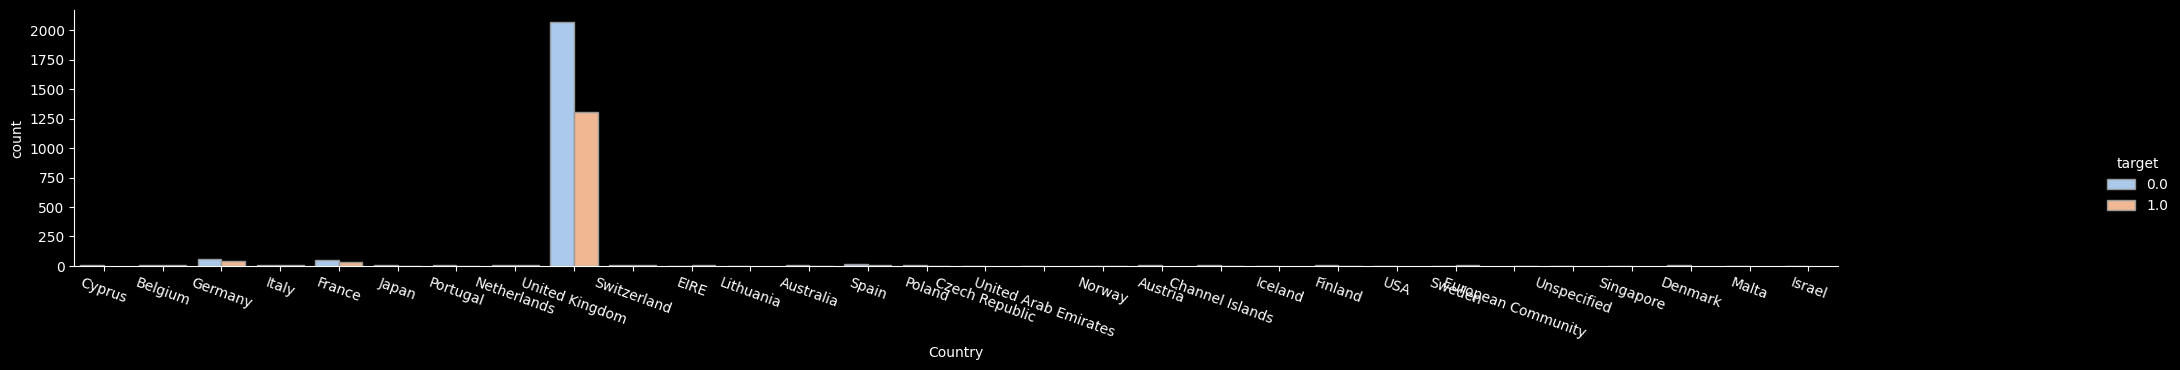

In [413]:
import seaborn as sns
import matplotlib.pyplot as plt
%matplotlib inline
plt.style.use(['dark_background'])

# target 기준(hue,색상)으로 구분하여 Plot
sns.catplot(x="Country", hue="target", kind="count",palette="pastel", edgecolor=".6",data=df_mart);
plt.xticks(rotation=-20) #각도 

plt.gcf().set_size_inches(25, 3)

In [414]:
# EDA value
df_cat = pd.DataFrame(df_mart['Country'].value_counts()).reset_index()
df_cat['ratio'] = df_cat['count'] / df_cat['count'].sum()
df_cat

,Country,count,ratio
0,United Kingdom,3372,0.904992
1,Germany,102,0.027375
2,France,86,0.023081
3,Belgium,22,0.005904
4,Spain,21,0.005636
5,Italy,11,0.002952
6,Netherlands,11,0.002952
7,Portugal,9,0.002415
8,Poland,9,0.002415
9,EIRE,9,0.002415


In [415]:
df_mart['Country'] = np.where(df_mart['Country'] == 'United Kingdom', 'UK', 'ETC')#United Kingdom 이면 UK 아니면 ETC
df_mart['Country'].value_counts()

Country
UK     3372
ETC     354
Name: count, dtype: int64

In [416]:
# target , non-target count
iv = df_mart.groupby('Country')[['target', 'n_target']].sum().reset_index()

# good_pct /bad_pct 계산
iv['good_pct'] = iv['target'] / iv['target'].sum()
iv['bad_pct'] = iv['n_target'] / iv['n_target'].sum()

# t_ratio
iv['t_ratio'] = iv['target'] / (iv['target'] + iv['n_target'])

iv['val'] = 'Country'

for i in range(len(iv['Country'])) :
  iv.loc[i, 'iv'] = (iv.loc[i,'good_pct'] - iv.loc[i,'bad_pct']) * math.log(iv.loc[i,'good_pct']/iv.loc[i,'bad_pct'])

iv

,Country,target,n_target,good_pct,bad_pct,t_ratio,val,iv
0,ETC,133.0,221,0.092618,0.096507,0.375706,Country,0.000160
1,UK,1303.0,2069,0.907382,0.903493,0.386418,Country,0.000017


In [417]:
iv['iv'].sum() # not much information 

0.00017659066476091975

In [418]:
# final data mart
df_mart = pd.DataFrame(df_mart)
#df_mart.to_csv('df_mart.csv', index=False)

### Optimal Binning

In [419]:
pip install optbinning


[notice] A new release of pip is available: 25.0.1 -> 25.1
[notice] To update, run: pip install --upgrade pip
Note: you may need to restart the kernel to use updated packages.


In [420]:
#  numeric
from optbinning import OptimalBinning

integer_list = ['total_amt', 'max_amt', 'min_amt', 'total_cnt','max_cnt', 'min_cnt', 'total_qty', 'max_qty', 'min_qty']
iv_df = []

for i in integer_list :
  variable = i
  x = df_mart[variable].values
  y = df_mart.target
  # max_n_prebins
  optb = OptimalBinning(name=variable, dtype="numerical", solver="cp", max_n_prebins=3) 
  optb.fit(x, y)
  print("split points : ", optb.splits)

  binning_table = optb.binning_table
  v1 = binning_table.build()

  df = pd.DataFrame({'val' : variable,
                     'IV' : [v1.loc['Totals','IV']]})
  iv_df.append(df)

iv_df = pd.concat(iv_df).reset_index(drop=True)
iv_df.sort_values(by=['IV'], ascending = False)

# rank are still same
# binning_table.plot(metric="event_rate")

split points :  [ 480.44999695 1164.02502441]
split points :  [ 237.06500244 1272.79998779]
split points :  [109.25500107 289.97999573]
split points :  [1.5 2.5]
split points :  [ 2.5 12.5]
split points :  [ 4.5 25.5]
split points :  [175.5 661.5]
split points :  [ 26.5 137. ]
split points :  [3.5 5.5]


,val,IV
3,total_cnt,0.283918
0,total_amt,0.203491
6,total_qty,0.160114
1,max_amt,0.128935
7,max_qty,0.079832
4,max_cnt,0.032054
2,min_amt,0.024855
5,min_cnt,0.017754
8,min_qty,0.009636


In [421]:
v1

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,"(-inf, 3.50)",2723,0.730811,1700,1023,0.375689,0.041198,0.001234,0.000154
1,"[3.50, 5.50)",350,0.093935,190,160,0.457143,-0.29484,0.008389,0.001045
2,"[5.50, inf)",653,0.175255,400,253,0.387443,-0.008615,0.000013,0.000002
3,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
4,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,3726,1.000000,2290,1436,0.385400,,0.009636,0.001201


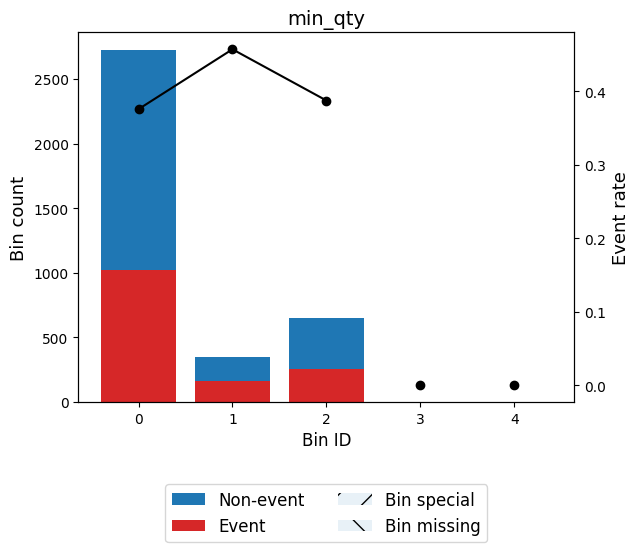

In [422]:
plt.style.use('default')
binning_table.plot(metric="event_rate")

The variable min_qty appears to have some ability to distinguish between Event and Non-event cases.

In particular, Bin 1 shows the highest event rate, while Bin 0 has a relatively lower rate, indicating good discriminatory power.

Bins 3 and 4 contain very few data points, making them insignificant for interpretation and likely safe to ignore.

This variable may be meaningful for classification models, as it shows a relationship with the target variable.

,Bin,Count,Count (%),Non-event,Event,Event rate,WoE,IV,JS
0,[UK],3372,0.904992,2069,1303,0.386418,-0.004294,0.000017,0.000002
1,[ETC],354,0.095008,221,133,0.375706,0.041123,0.000160,0.000020
2,Special,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
3,Missing,0,0.000000,0,0,0.000000,0.0,0.000000,0.000000
Totals,,3726,1.000000,2290,1436,0.385400,,0.000177,0.000022


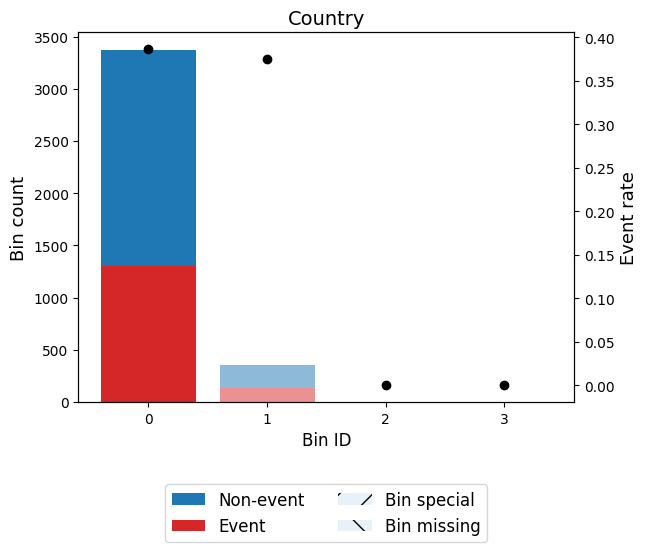

In [423]:
# ▶ Categorical
variable_cat = "Country"
x_cat = df_mart[variable_cat].values
y_cat = df_mart.target

optb = OptimalBinning(name=variable_cat, dtype="categorical", solver="mip",
                      cat_cutoff=0.1) # 카테고리컬 컷오프, 10프로 차지하지 않는 것들은 잡음으로 etc 로?

optb.fit(x_cat, y_cat)
optb.splits

binning_table = optb.binning_table
display(binning_table.build())

binning_table.plot(metric="event_rate")